In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import dask.dataframe as dd

In [2]:
import os

data_folder = "./maximas_data"
# data is structured as: f"{name}-{time_id}
# Get all files in the data folder
files = os.listdir(data_folder)

# Extract names and time_ids from filenames
names = set()
time_ids = set()

for file in files:
    if '-' in file:
        parts = file.split('-')
        if len(parts) >= 2:
            name = parts[0]
            time_id = parts[1].split('.')[0]  # Remove file extension if present
            names.add(name)
            time_ids.add(time_id)

print(f"Unique names: {sorted(names)}")
print(f"Unique time IDs: {sorted(time_ids)}")



Unique names: ['series0_CBM_k2', 'series0_CBM_k4', 'series0_SBM', 'series1_CBM_k2', 'series1_CBM_k4', 'series1_SBM', 'series2_CBM_k2', 'series2_CBM_k4', 'series2_SBM', 'series3_CBM_k2', 'series3_CBM_k4', 'series3_SBM']
Unique time IDs: ['1745469245', '1745469247', '1745469479', '1745469959', '1745469962']


In [3]:
maximas_data = {}
for name in names:
    maximas_data[name] = []
    for time_id in time_ids:
        path = f"{data_folder}/{name}-{time_id}"
        if os.path.exists(path):
            # Read the parquet file into a Dask DataFrame
            maximas_data[name].append(dd.read_parquet(path))
    maximas_data[name] = dd.concat(maximas_data[name], axis=0)

In [4]:
points_per_series = 655360
points_per_block = points_per_series // 10

disjoint_maximas = {}

for name in maximas_data.keys():
    # Compute the disjoint maximas for each series
    disjoint_maximas[name] = maximas_data[name].loc[0::points_per_block].compute()
    break

In [ ]:
standard_disjoint_estimator = {}
for name in disjoint_maximas.keys():
    #take the mean of every 10 points, reducing the number of points by 10
    standard_disjoint_estimator[name] = disjoint_maximas[name].groupby(disjoint_maximas[name].index // 10).mean()

bs_disjoint_estimator = {}

for name in disjoint_maximas.keys():
    # For bootstrap, we need to work with computed data (Pandas DataFrame)
    df_computed = disjoint_maximas[name]
    result = {}
    
    # Group the data by every 10 points
    groups = df_computed.groupby(df_computed.index // 10)
    
    # For each group, perform bootstrap sampling
    for group_idx, group_data in groups:
        values = group_data['value'].values
        # Bootstrap with 100 samples
        bootstrap_means = np.array([np.random.choice(values, size=len(values), replace=True).mean() 
                                   for _ in range(100)])
        result[group_idx] = bootstrap_means.mean()
    
    # Convert the result to a DataFrame
    bs_disjoint_estimator[name] = pd.DataFrame({'value': pd.Series(result)})

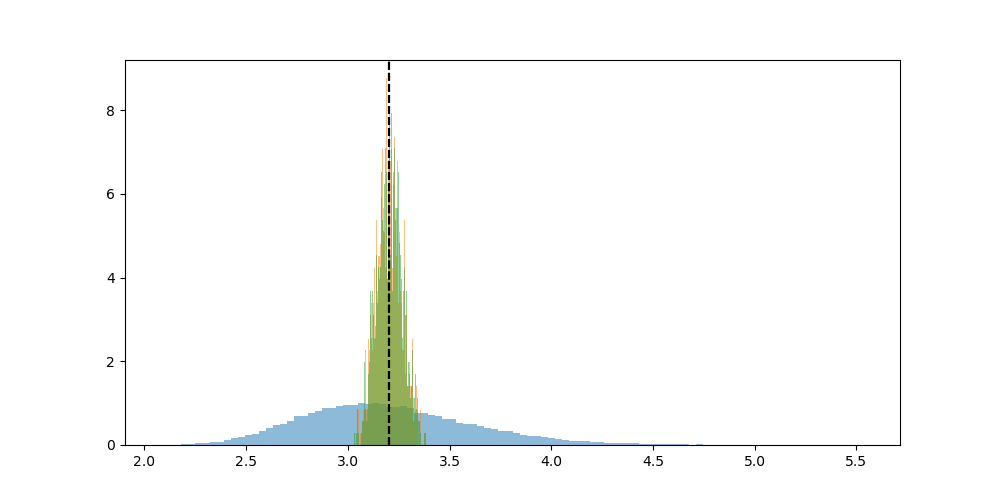

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for name, df in disjoint_maximas.items():
    # plot the empirical pdf of the disjoint maximas
    ax.hist(df, bins=100, density=True, alpha=0.5, label=name)
    # plot a vertical line at the mean
    mean = df.mean()
    ax.axvline(mean['value'], color='k', linestyle='--', label=f"{name} mean")

for name, df in standard_disjoint_estimator.items():
    # plot the empirical pdf of the disjoint maximas
    ax.hist(df, bins=100, density=True, alpha=0.5, label=name)
    # plot a vertical line at the mean
    mean = df.mean()
    ax.axvline(mean['value'], color='k', linestyle='--', label=f"{name} mean")

# Plot the bootstrap disjoint estimator
for name, df in bs_disjoint_estimator.items():
    # plot the empirical pdf of the disjoint maximas
    ax.hist(df, bins=100, density=True, alpha=0.5, label=name)
    # plot a vertical line at the mean
    mean = df.mean()
    ax.axvline(mean['value'], color='k', linestyle='--', label=f"{name} mean")

In [18]:
import numpy as np
import pandas as pd

# Function to calculate bias, standard error, and MSE
def calculate_metrics(estimator, true_mean):
    """
    Calculate bias, standard error, and MSE for an estimator.
    
    Parameters:
    -----------
    estimator : pandas.DataFrame
        DataFrame containing the estimates
    true_mean : float
        The true mean value (or reference value)
    
    Returns:
    --------
    dict
        Dictionary containing bias, standard error, and MSE
    """
    values = estimator['value'].values
    bias = np.mean(values) - true_mean
    standard_error = np.std(values, ddof=1)
    mse = np.mean((values - true_mean)**2)
    
    return {
        'bias': bias,
        'standard_error': standard_error,
        'mse': mse
    }

# Function to compare estimators
def compare_estimators(true_df, estimators_dict, name):
    """
    Compare multiple estimators against a true dataset.
    
    Parameters:
    -----------
    true_df : pandas.DataFrame
        DataFrame containing the true data
    estimators_dict : dict
        Dictionary of estimators, with keys as estimator names
    name : str
        Name of the dataset being evaluated
    
    Returns:
    --------
    dict
        Results dictionary with metrics for each estimator
    """
    # Calculate the true mean
    true_mean = true_df['value'].mean()
    print(f"\nMetrics for {name}:")
    print(f"Reference mean: {true_mean:.6f}")
    
    results = {'true_mean': true_mean}
    
    # Calculate metrics for each estimator
    for estimator_name, estimator_df in estimators_dict.items():
        metrics = calculate_metrics(estimator_df, true_mean)
        print(f"\n{estimator_name} Estimator:")
        print(f"  Bias: {metrics['bias']:.6f}")
        print(f"  Standard Error: {metrics['standard_error']:.6f}")
        print(f"  MSE: {metrics['mse']:.6f}")
        
        results[estimator_name] = metrics
    
    return results

# Process all datasets
all_results = {}
for name in disjoint_maximas.keys():
    # Create a dictionary of estimators to compare
    estimators = {}
    if name in standard_disjoint_estimator:
        estimators['Standard'] = standard_disjoint_estimator[name]
    if name in bs_disjoint_estimator:
        estimators['Bootstrap'] = bs_disjoint_estimator[name]
    
    # Compare the estimators
    all_results[name] = compare_estimators(disjoint_maximas[name], estimators, name)

# Optional: Create a summary table for comparison
summary_df = pd.DataFrame(columns=['Dataset', 'Estimator', 'Bias', 'Standard Error', 'MSE'])

row = 0
for dataset, results in all_results.items():
    for estimator_name, metrics in results.items():
        if estimator_name != 'true_mean':
            summary_df.loc[row] = [
                dataset, 
                estimator_name, 
                metrics['bias'] if 'bias' in metrics else None,
                metrics['standard_error'] if 'standard_error' in metrics else None,
                metrics['mse'] if 'mse' in metrics else None
            ]
            row += 1

if len(summary_df) > 0:
    print("\nSummary Table:")
    print(summary_df)


Metrics for series2_CBM_k4:
Reference mean: 3.204195

Standard Estimator:
  Bias: 0.000000
  Standard Error: 0.061084
  MSE: 0.003727

Bootstrap Estimator:
  Bias: -0.000019
  Standard Error: 0.061146
  MSE: 0.003735

Summary Table:
          Dataset  Estimator      Bias  Standard Error       MSE
0  series2_CBM_k4   Standard  0.000000        0.061084  0.003727
1  series2_CBM_k4  Bootstrap -0.000019        0.061146  0.003735
